#Mini-Project #2: Multiple Linear Regression and Product Quality

**Please follow the step-by-step instructions** to:  
1. **Develop the Code** – Write the necessary code to generate the desired outputs*.  
2. **Annotate/Explain Steps** – Provide annotations or explanations of your coding steps where appropriate.  
3. **Disclose GenAI Usage** – If Generative AI was used, include the prompts and explain how it assisted in producing code and/or annotations.  
4. **Answer Analysis Questions** – Complete the analysis questions posted on *Canvas*, using insights from your notebook outputs.  

**Note:*
- Unless otherwise specified, minor variations in formatting (e.g., labels, colors, titles) are acceptable.
- Run all cells in order, even those where you don't enter information or code.

## Business and Data Understanding
In light of recent concrete failures, manufacturers are conducting better tests for determining strength.

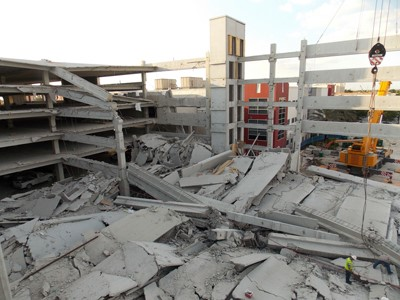

You have been asked by the production department of a concrete manufacturer to investigate what components contribute to **compressive strength**. This is an important mission because a large contract hinges on the company's ability to manufacture concrete strong enough to withstand the load of the new Innovation Research Center.

The Concrete Dataset provides essential information on concrete mixtures, including ingredient composition and strength characteristics. It's utilized by engineers and researchers for optimizing mix designs, ensuring quality control, developing predictive models, and promoting sustainable construction practices. This dataset plays a crucial role in advancing knowledge in civil engineering and construction management. Key attributes within the dataset include:

- Cement: The quantity of cement used in the concrete mixture, which serves as the binding agent.
- Blast Furnace Slag: The amount of blast furnace slag, a supplementary cementitious material, included in the mixture to enhance durability and workability.
- Fly Ash: The proportion of fly ash, another commonly used supplementary cementitious material, which contributes to improved strength and reduced environmental impact.
- Water: The volume of water added to the mixture to achieve the desired consistency and hydration of cement particles.
- Superplasticizer: The dosage of superplasticizer, an additive used to enhance workability and reduce water content while maintaining fluidity.
- Coarse Aggregate: The quantity of coarse aggregate, typically gravel or crushed stone, included in the mixture to provide strength and stability.
- Fine Aggregate: The amount of fine aggregate, such as sand or crushed stone dust, used to fill voids and improve cohesion in the concrete matrix.
- Age (Days): The age of the concrete specimen at the time of testing, which influences its strength development over time.
- Concrete Strength (MPa): The compressive strength of the concrete specimen, measured in megapascals (MPa), representing its ability to withstand axial loads.


All volumetric predictors are measured in kilograms/cubic meter and Age is measured in days. For example, a value of Superplasticizer being 5 means 5kg of it is present in one cubic meter of concrete.

This data analytic project will take you through EDA, data preprocessing, and two types of linear regression models (explanatory and predictive).

The libraries and dataset will be loaded for you. You must develop the code required to answer the questions about your concrete strength and enter it where specified. **You can reference <a href = "https://drive.google.com/file/d/1IQjbvly-miQzKTrcdIdnt1G_y98FMO9w/view?usp=share_link"> Tutuorial: Multiple Linear Regression </a> for all the code needed.** The tutorial should be sufficient for you to complete the project.

Nevertheless, if you use GenAI in any step of this project, please disclose it using the following format.

**GenAI Usage Disclosure**

"""
GenAI Usage: [If applicable, please paste the exact prompts you used here.
If no GenAI was used, write "None."]
"""


### BEGIN SOLUTION





### END SOLUTION

### Load required packages by running the following cell of codes:

In [ ]:
%pip install pandas scikit-learn matplotlib seaborn

In [ ]:

%matplotlib inline
import pandas as pd
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import matplotlib.pyplot as plt

### Load data

In [ ]:
data_df = pd.read_csv("https://raw.githubusercontent.com/rul110/datasets/refs/heads/main/concrete.csv")

# Note: original dataset

## Step 1: Data Preprocessing

### Step 1.1: Dataset overview

Display dataset variable information and the first 10 observations of the dataset.

***Your output should look like this:***  

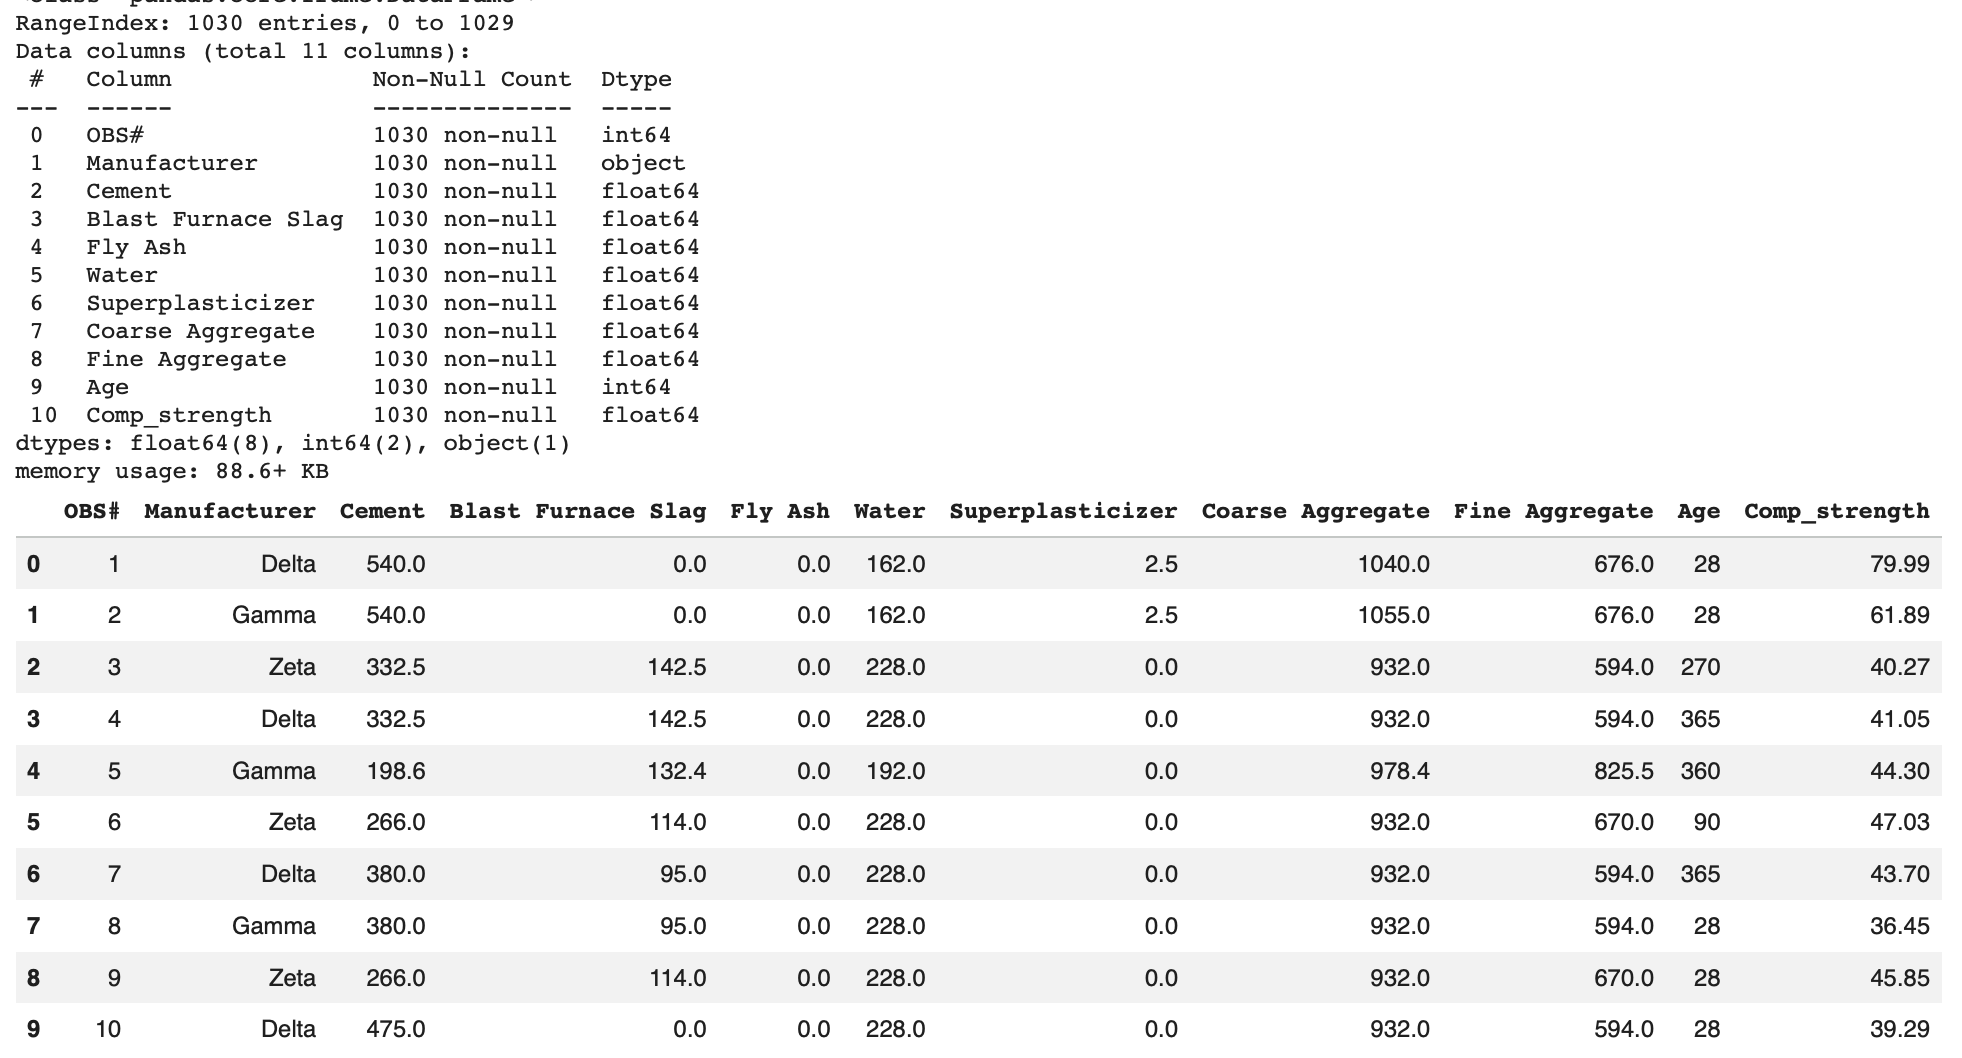

In [ ]:
data_df.info()
data_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   OBS#                1030 non-null   int64  
 1   Manufacturer        1030 non-null   object 
 2   Cement              1030 non-null   float64
 3   Blast Furnace Slag  1030 non-null   float64
 4   Fly Ash             1030 non-null   float64
 5   Water               1030 non-null   float64
 6   Superplasticizer    1030 non-null   float64
 7   Coarse Aggregate    1030 non-null   float64
 8   Fine Aggregate      1030 non-null   float64
 9   Age                 1030 non-null   int64  
 10  Comp_strength       1030 non-null   float64
dtypes: float64(8), int64(2), object(1)
memory usage: 88.6+ KB


,OBS#,Manufacturer,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Comp_strength
0,1,Delta,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,2,Gamma,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,3,Zeta,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,4,Delta,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,5,Gamma,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
5,6,Zeta,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
6,7,Delta,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70
7,8,Gamma,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
8,9,Zeta,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
9,10,Delta,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


### Step 1.2: Clean variables
- Remove the first column, "OBS#", from data_df, as it's not a valid predictor.
- Replace all spaces in the remaining variable names with underscore characters and display the updated names.

***Your output should look like this:***

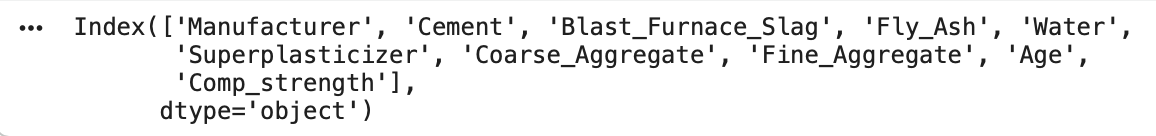

In [ ]:
# Step 1.2: Clean variables

# 1) remove OBS# (first column)
data_df = data_df.drop(columns=["OBS#"])

# 2) replace spaces with underscores in column names
data_df.columns = data_df.columns.str.replace(" ", "_")

# 3) display updated column names
list(data_df.columns)

['Manufacturer',
 'Cement',
 'Blast_Furnace_Slag',
 'Fly_Ash',
 'Water',
 'Superplasticizer',
 'Coarse_Aggregate',
 'Fine_Aggregate',
 'Age',
 'Comp_strength']

### Step 1.3: Summary statistics

- Show summary satistics of all numerical variables.
- Show value counts of each category in each categorical variable.

***Your output should look like this:***


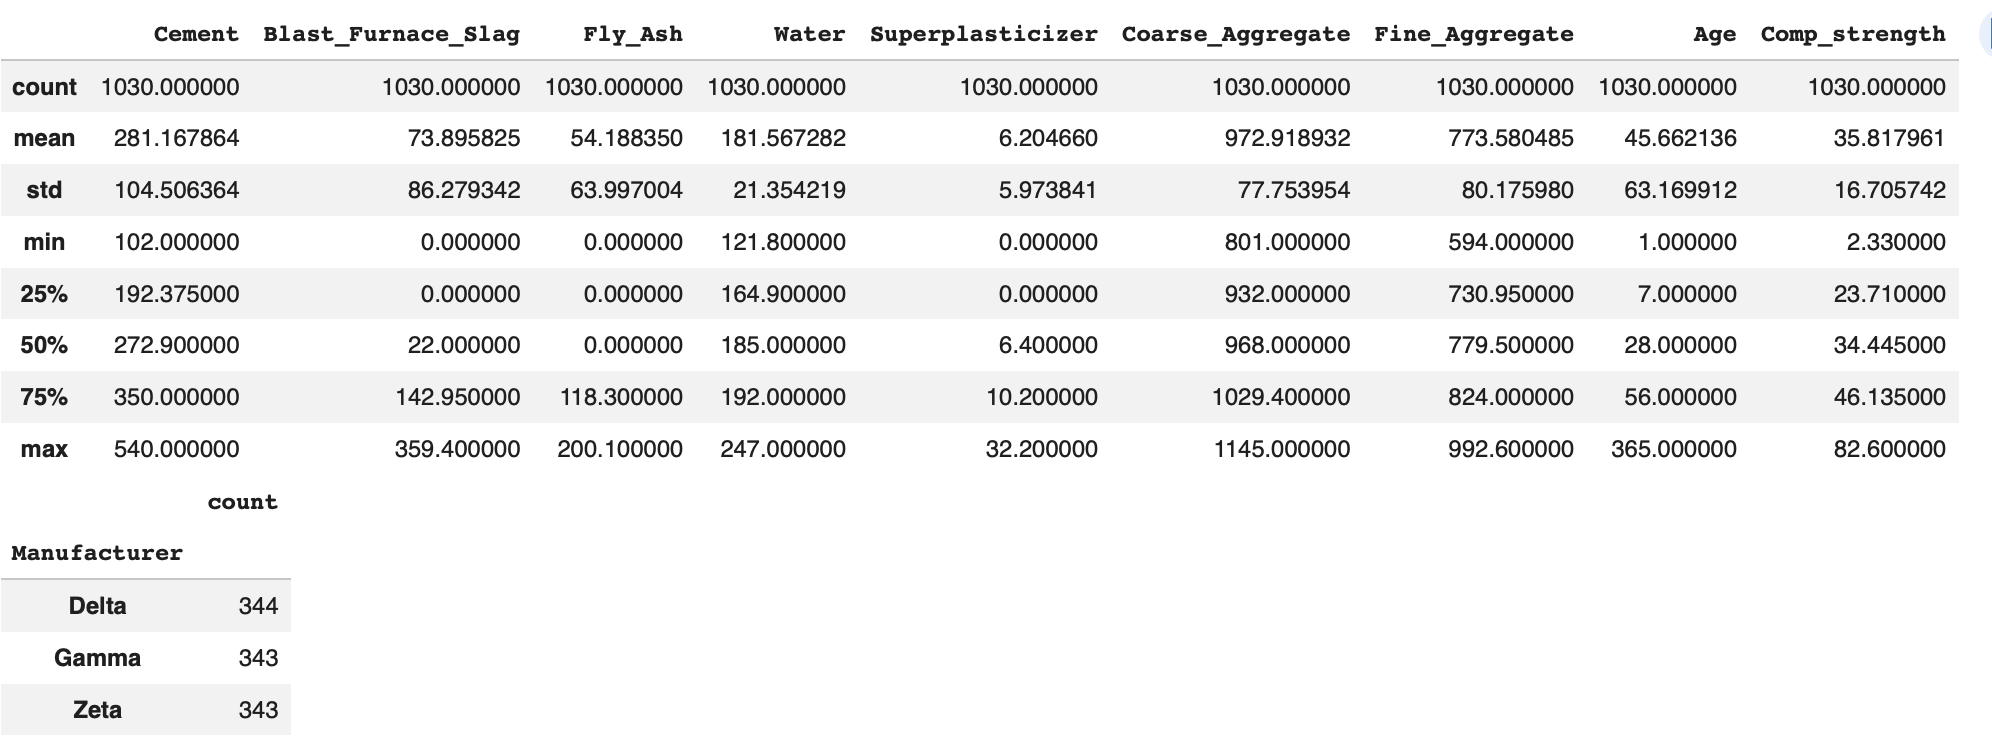

In [ ]:
# Summary statistics for numeric columns
data_df.describe()

# Value counts for categorical columns (object / category)
cat_cols = data_df.select_dtypes(include=["object", "category"]).columns
for c in cat_cols:
    print(f"\n--- {c} ---")
    print(data_df[c].value_counts(dropna=False))

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Comp_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000



--- Manufacturer ---
Manufacturer
Delta    344
Gamma    343
Zeta     343
Name: count, dtype: int64


### Step 1.4: Categorical variables

- Transform the categorical variables using dummy encoding and drop the first dummy variable.
- Display the first 5 observations after the transformation.



***Your output should look like this:***  

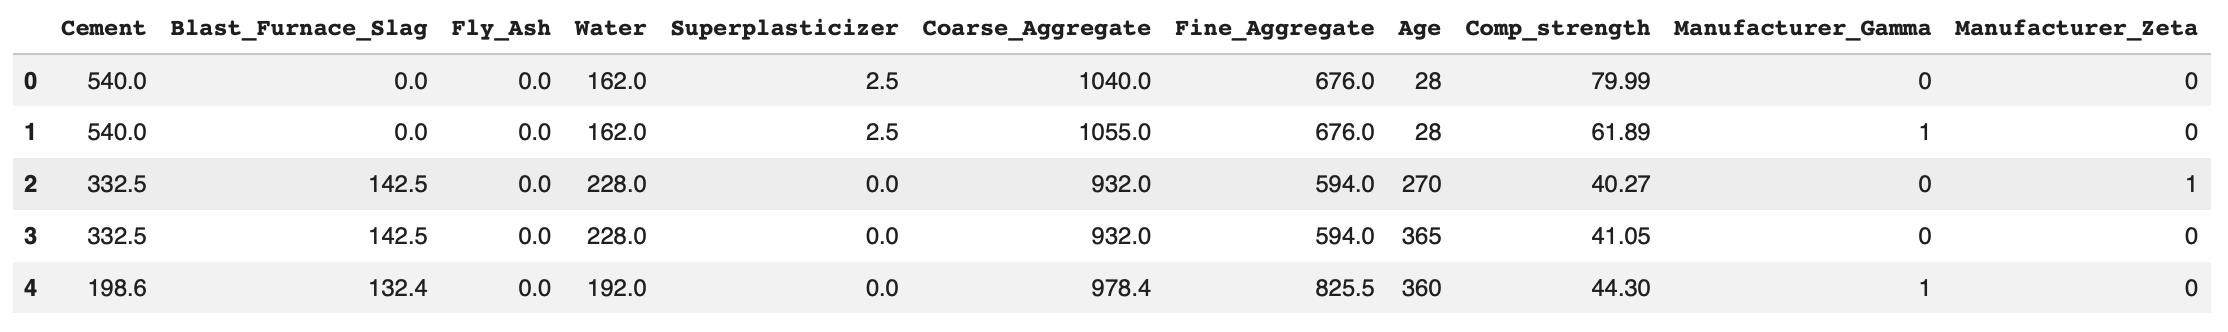

In [ ]:
data_encoded = pd.get_dummies(data_df, drop_first=True)

print("Original shape:", data_df.shape)
print("Encoded shape:", data_encoded.shape)

data_encoded.head()

Original shape: (1030, 10)
Encoded shape: (1030, 11)


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Comp_strength,Manufacturer_Gamma,Manufacturer_Zeta
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,False,False
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,True,False
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,False,True
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,False,False
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,True,False


### Step 1.5: Correlations

- Print pairwise correlations between all variables.
- Create pairwise scatterplots for these variables: ['Comp_strength', 'Cement',  'Water', 'Superplasticizer', 'Age']

***Your output should look like this:***  

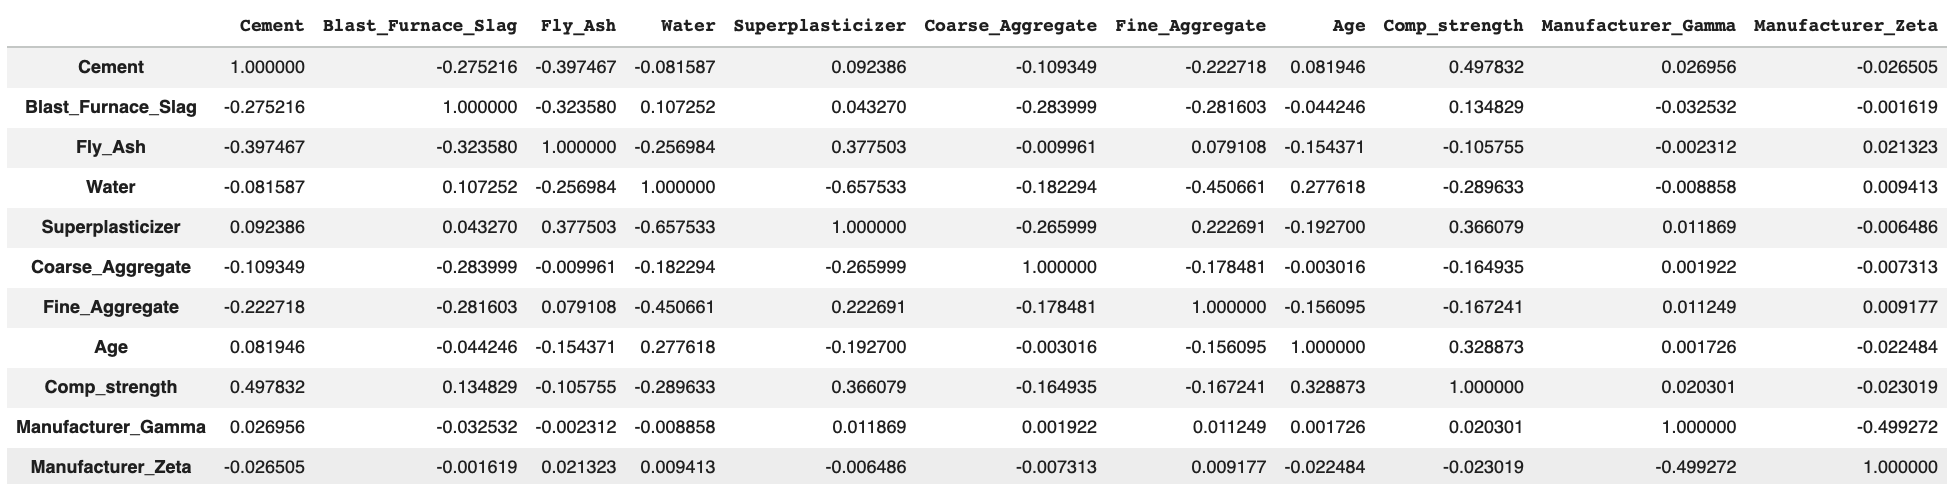


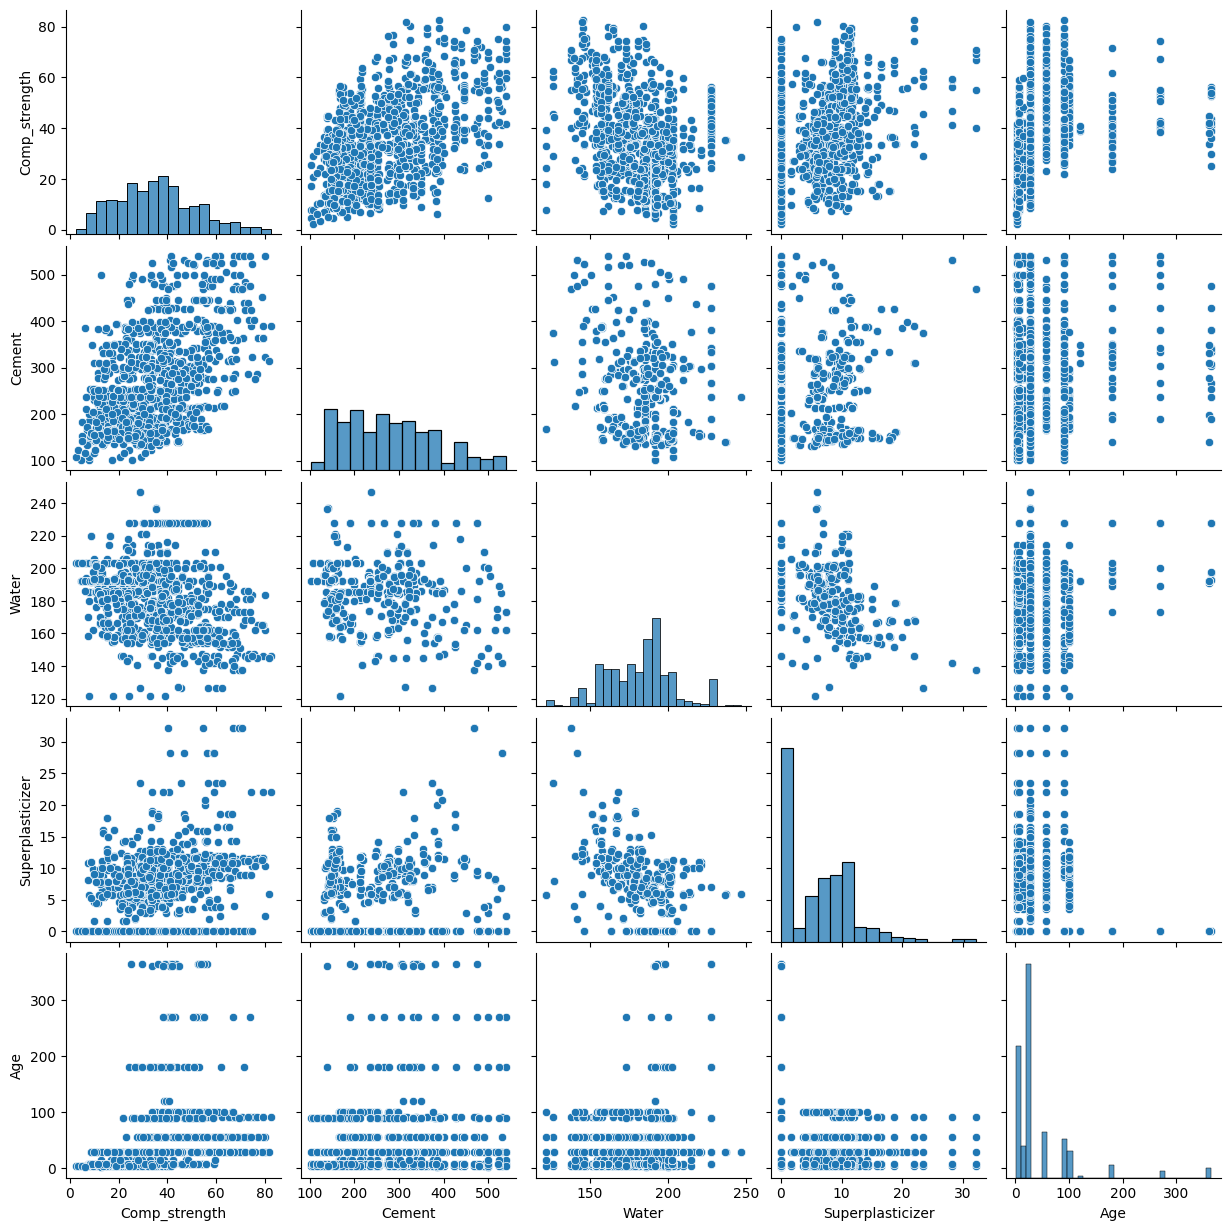

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Comp_strength,Manufacturer_Gamma,Manufacturer_Zeta
Cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832,0.026956,-0.026505
Blast_Furnace_Slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829,-0.032532,-0.001619
Fly_Ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755,-0.002312,0.021323
Water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633,-0.008858,0.009413
Superplasticizer,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079,0.011869,-0.006486
Coarse_Aggregate,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935,0.001922,-0.007313
Fine_Aggregate,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241,0.011249,0.009177
Age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873,0.001726,-0.022484
Comp_strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000,0.020301,-0.023019
Manufacturer_Gamma,0.026956,-0.032532,-0.002312,-0.008858,0.011869,0.001922,0.011249,0.001726,0.020301,1.000000,-0.499272


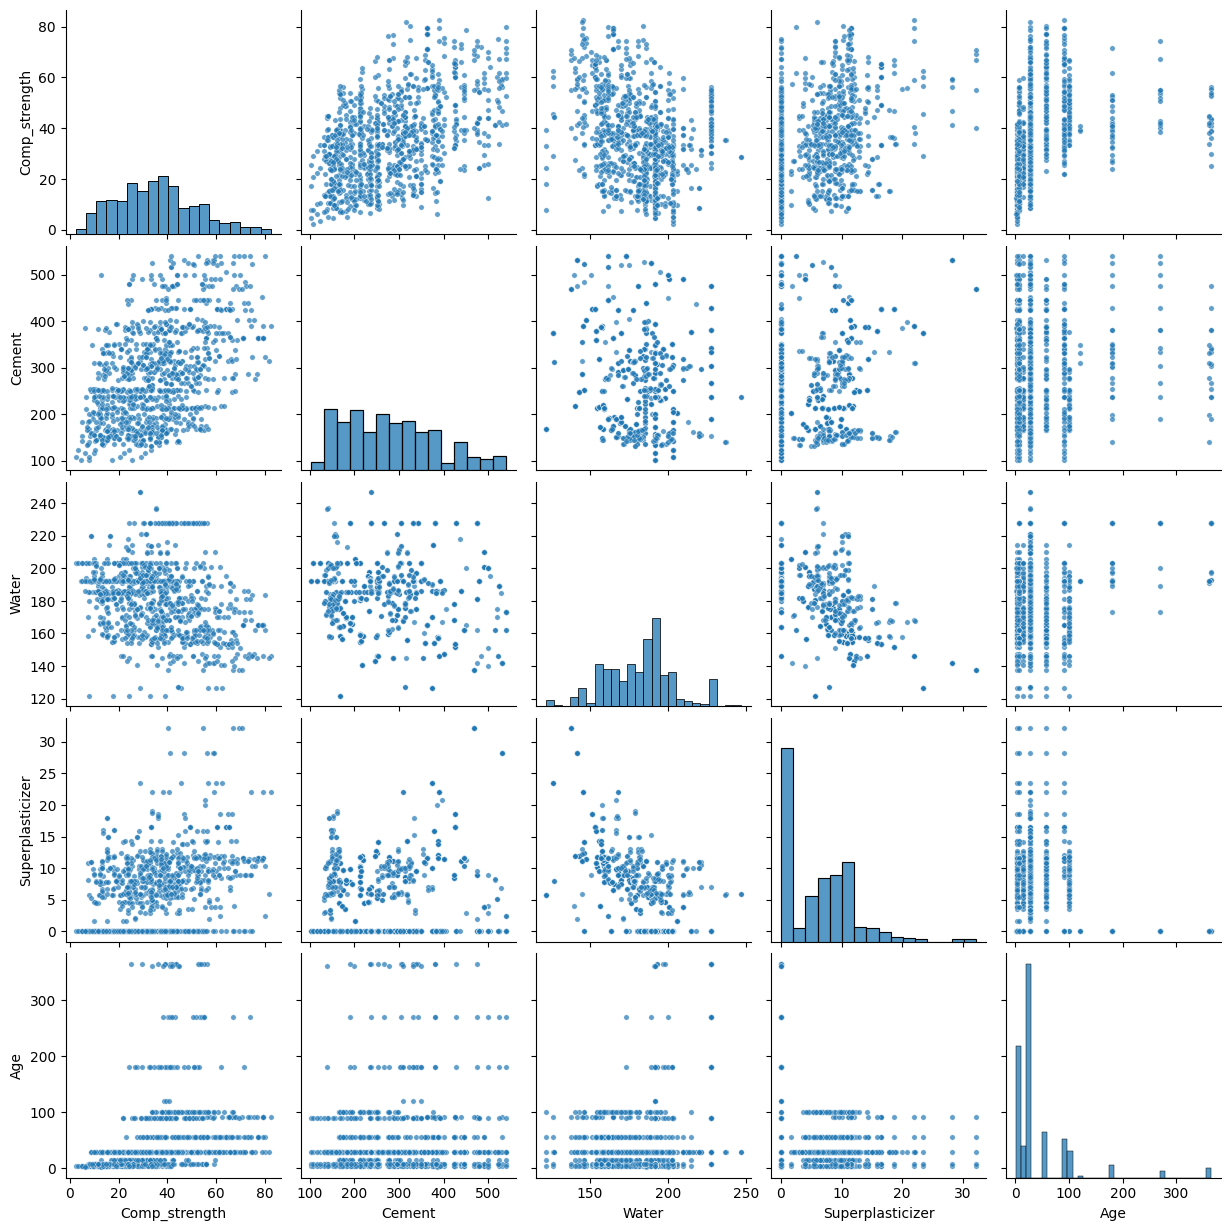

In [ ]:

# Print pairwise correlations between all variables
corr_matrix = data_encoded.corr(numeric_only=True)
corr_matrix

# Pairwise scatterplots for specified variables
cols_for_plot = ['Comp_strength', 'Cement', 'Water', 'Superplasticizer', 'Age']

sns.pairplot(
    data_encoded[cols_for_plot],
    diag_kind="hist",
    plot_kws={"s": 15, "alpha": 0.7}
)
plt.show()

### Step 1.6: Input and output variables

- Save the target variable Comp_strength into a series object `y`, which is your output variable.
- Save all the other variables as a Dataframe object `X`, which denotes your input variable.
- Print the shapes of X and y
- Show whether there is any missing values in the input and output variables

***Your output should look like this:***  

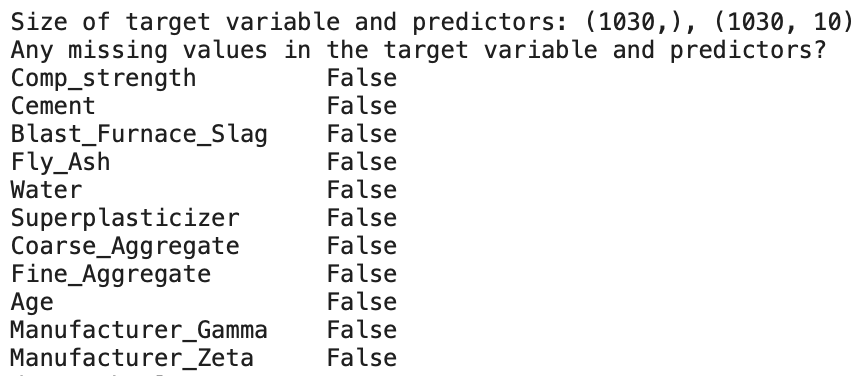



In [ ]:
# Output (target)
y = data_encoded["Comp_strength"]

# Input (predictors)
X = data_encoded.drop(columns=["Comp_strength"])

# Print shapes (match the example)
print(f"Size of target variable and predictors: {y.shape}, {X.shape}")

# Missing values per variable (match the example: variable names -> True/False)
print("Any missing values in the target variable and predictors?")

missing_y = pd.Series({y.name: y.isna().any()})     # one True/False for target
missing_X = X.isna().any()                          # True/False for each predictor column
missing_all = pd.concat([missing_y, missing_X])

print(missing_all)

Size of target variable and predictors: (1030,), (1030, 10)
Any missing values in the target variable and predictors?
Comp_strength         False
Cement                False
Blast_Furnace_Slag    False
Fly_Ash               False
Water                 False
Superplasticizer      False
Coarse_Aggregate      False
Fine_Aggregate        False
Age                   False
Manufacturer_Gamma    False
Manufacturer_Zeta     False
dtype: bool


## Step 2: Developing an explanatory model

### Step 2.1: Creating an explanatory model

- Create and run an explanatory linear regression model on the full data.
- Print out the coefficients and intercept.

*Annotate each step with comments using `#`.*  


***Your output should look like this:***  

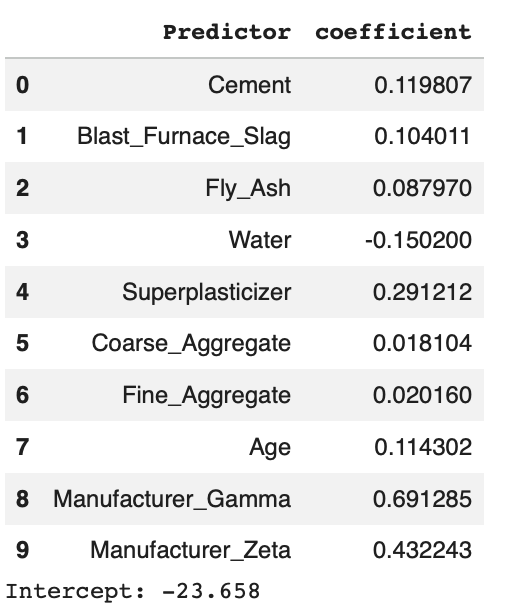

In [ ]:
from sklearn.linear_model import LinearRegression

# Fit linear regression on full data
lr_model = LinearRegression()
lr_model.fit(X, y)

# Create coefficient table in the same order as X columns
coef_df = pd.DataFrame({
    "Predictor": X.columns,
    "coefficient": lr_model.coef_
})

# Display coefficients
coef_df

# Display intercept (rounded like the example)
print(f"Intercept: {lr_model.intercept_:.3f}")

LinearRegression()

,Predictor,coefficient
0,Cement,0.119807
1,Blast_Furnace_Slag,0.104011
2,Fly_Ash,0.087970
3,Water,-0.150200
4,Superplasticizer,0.291212
5,Coarse_Aggregate,0.018104
6,Fine_Aggregate,0.020160
7,Age,0.114302
8,Manufacturer_Gamma,0.691285
9,Manufacturer_Zeta,0.432243


Intercept: -23.658


### Step 2.2: Explanatory model performance

Using the predict function, calculate model performance metrics including:
- $R^2$,
- Adjusted $R^2$,
- Mean Error,
- Mean Absolute Error (MAE),
- Root Mean Squared Error (RMSE), and
- Mean Absolute Percentage Error (MAPE).


*Annotate each step with comments using `#`.*  

***Your output should look like this:***  

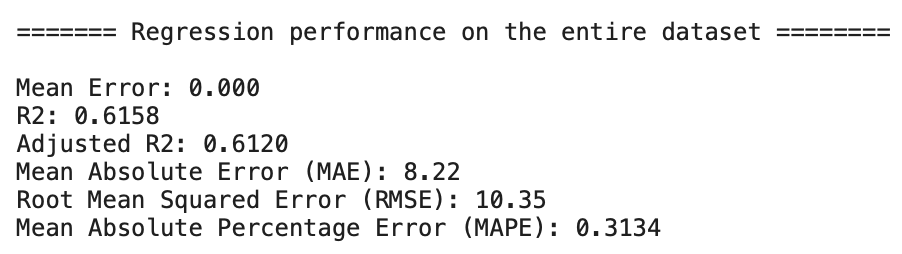

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions on full data
y_pred = lr_model.predict(X)

# Metrics
me = np.mean(y - y_pred)                               # Mean Error
r2 = r2_score(y, y_pred)
n = X.shape[0]                                         # number of observations
p = X.shape[1]                                         # number of predictors
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# IMPORTANT: MAPE as a decimal (not %)
mape = np.mean(np.abs((y - y_pred) / y))

# Print to match the example formatting
print("======= Regression performance on the entire dataset =======")
print(f"Mean Error: {me:.3f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")

======= Regression performance on the entire dataset =======
Mean Error: 0.000
R2: 0.6158
Adjusted R2: 0.6120
Mean Absolute Error (MAE): 8.22
Root Mean Squared Error (RMSE): 10.35
Mean Absolute Percentage Error (MAPE): 0.3134


## Step 3: Developing a predictive model

### Step 3.1: Split data


- Use the `train_test_split` function to divide the dataset into training and testing sets, assigning 75% of the samples to `train_X` and `train_y`, and 25% to `test_X` and `test_y`.
- Set the random seed to **15** for reproducibility. (**Important! This ensures you can obtain similar results as shown in the screenshots in the followin steps**)
- Print out the sizes of `train_X` and `test_X`.
- Show the first five observations of `train_X` and `test_X`, respectively


***Your display should look like this:***

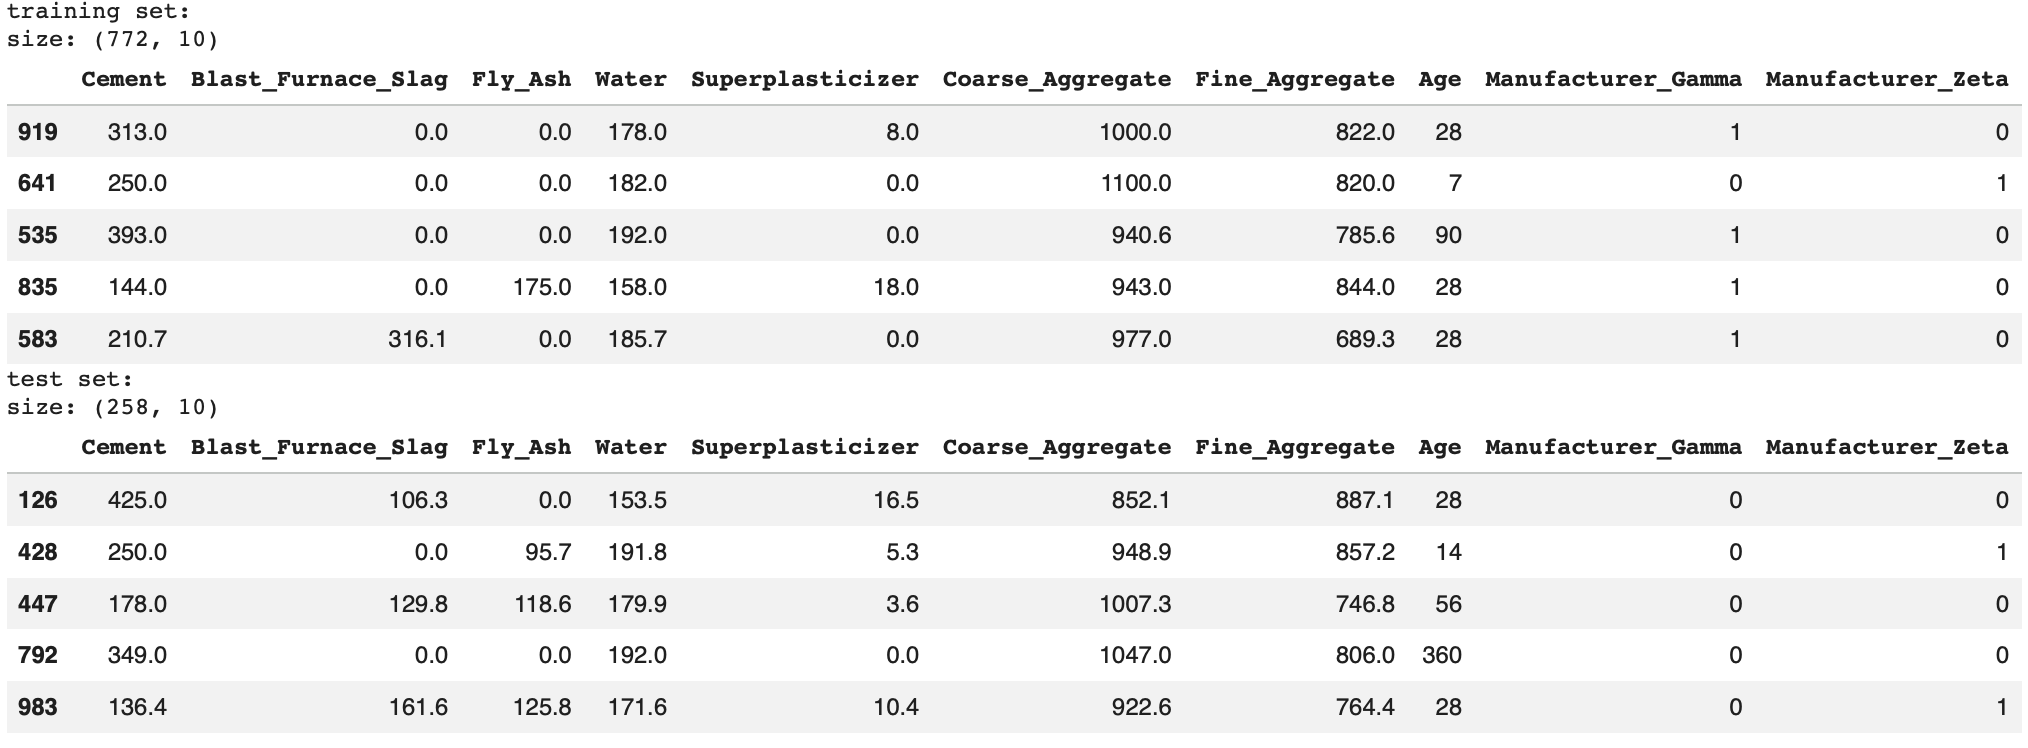

In [ ]:
from sklearn.model_selection import train_test_split

# Split data: 75% train, 25% test (random seed = 15)
train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.25, random_state=15
)

# Convert boolean dummy columns to 0/1 so they don't show True/False
bool_cols = train_X.select_dtypes(include=["bool"]).columns
train_X[bool_cols] = train_X[bool_cols].astype(int)
test_X[bool_cols]  = test_X[bool_cols].astype(int)

# Display sizes + first 5 observations (match example format)
print("training set:")
print(f"size: {train_X.shape}")
train_X.head()

print("\n" + "test set:")
print(f"size: {test_X.shape}")
test_X.head()

training set:
size: (772, 10)


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Manufacturer_Gamma,Manufacturer_Zeta
919,313.0,0.0,0.0,178.0,8.0,1000.0,822.0,28,1,0
641,250.0,0.0,0.0,182.0,0.0,1100.0,820.0,7,0,1
535,393.0,0.0,0.0,192.0,0.0,940.6,785.6,90,1,0
835,144.0,0.0,175.0,158.0,18.0,943.0,844.0,28,1,0
583,210.7,316.1,0.0,185.7,0.0,977.0,689.3,28,1,0



test set:
size: (258, 10)


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Manufacturer_Gamma,Manufacturer_Zeta
126,425.0,106.3,0.0,153.5,16.5,852.1,887.1,28,0,0
428,250.0,0.0,95.7,191.8,5.3,948.9,857.2,14,0,1
447,178.0,129.8,118.6,179.9,3.6,1007.3,746.8,56,0,0
792,349.0,0.0,0.0,192.0,0.0,1047.0,806.0,360,0,0
983,136.4,161.6,125.8,171.6,10.4,922.6,764.4,28,0,1


### Step 3.2: Build and evaluate predictive model

- Create and run a predictive linear regression model on the training data.
- calculate the following performance metrics on training and test data, respectively:
    - $R^2$,
    - Adjusted $R^2$,
    - Mean Error,
    - Mean Absolute Error (MAE),
    - Root Mean Squared Error (RMSE), and
    - Mean Absolute Percentage Error (MAPE).

*Annotate each step with comments using `#`.*  

***Your display should look like this:***

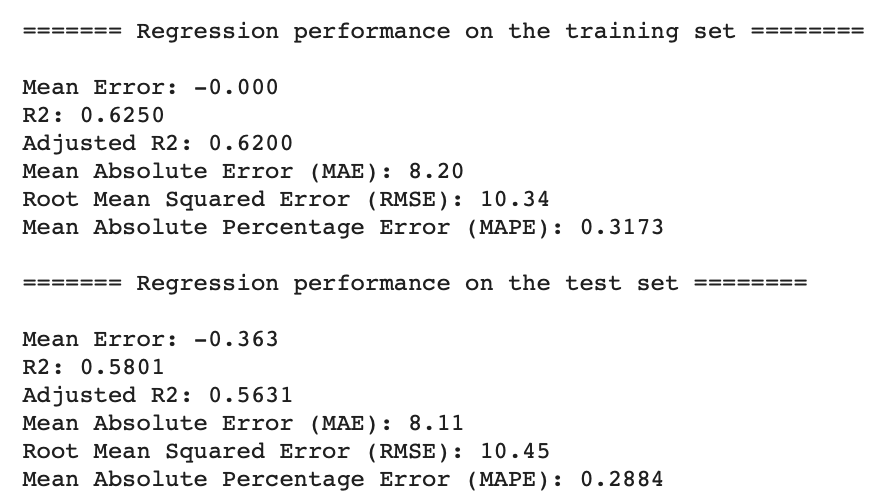

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train linear regression on training set
pred_lr = LinearRegression()
pred_lr.fit(train_X, train_y)

# ---- Training set metrics ----
train_pred = pred_lr.predict(train_X)

train_me = np.mean(train_y - train_pred)
train_r2 = r2_score(train_y, train_pred)
n_train = train_X.shape[0]
p = train_X.shape[1]
train_adj_r2 = 1 - (1 - train_r2) * (n_train - 1) / (n_train - p - 1)
train_mae = mean_absolute_error(train_y, train_pred)
train_rmse = np.sqrt(mean_squared_error(train_y, train_pred))
train_mape = np.mean(np.abs((train_y - train_pred) / train_y))  # decimal

print("======= Regression performance on the training set =======")
print(f"Mean Error: {train_me:.3f}")
print(f"R2: {train_r2:.4f}")
print(f"Adjusted R2: {train_adj_r2:.4f}")
print(f"Mean Absolute Error (MAE): {train_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {train_rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {train_mape:.4f}")

# ---- Test set metrics ----
test_pred = pred_lr.predict(test_X)

test_me = np.mean(test_y - test_pred)
test_r2 = r2_score(test_y, test_pred)
n_test = test_X.shape[0]
test_adj_r2 = 1 - (1 - test_r2) * (n_test - 1) / (n_test - p - 1)
test_mae = mean_absolute_error(test_y, test_pred)
test_rmse = np.sqrt(mean_squared_error(test_y, test_pred))
test_mape = np.mean(np.abs((test_y - test_pred) / test_y))  # decimal

print("\n======= Regression performance on the test set =======")
print(f"Mean Error: {test_me:.3f}")
print(f"R2: {test_r2:.4f}")
print(f"Adjusted R2: {test_adj_r2:.4f}")
print(f"Mean Absolute Error (MAE): {test_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {test_rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {test_mape:.4f}")

test_me = me
test_r2 = r2
test_adj_r2 = adj_r2
test_mae = mae
test_rmse = rmse
test_mape = mape

LinearRegression()

======= Regression performance on the training set =======
Mean Error: -0.000
R2: 0.6250
Adjusted R2: 0.6200
Mean Absolute Error (MAE): 8.20
Root Mean Squared Error (RMSE): 10.34
Mean Absolute Percentage Error (MAPE): 0.3173

======= Regression performance on the test set =======
Mean Error: -0.363
R2: 0.5801
Adjusted R2: 0.5631
Mean Absolute Error (MAE): 8.11
Root Mean Squared Error (RMSE): 10.45
Mean Absolute Percentage Error (MAPE): 0.2884


### Step 3.3: Building model using forward feature selection


- Implement **forward selection** with 4-fold cross validation on the training set using `SequentialFeatureSelector` to select features. Features are added if $R^2$ is incremented by at least 0.001 between two consecutive feature additions.
- Print the features selected.
- Build and run a regression model using the selected features on the training set.
- calculate the following performance metrics on the test data:
    - $R^2$,
    - Adjusted $R^2$,
    - Mean Error,
    - Mean Absolute Error (MAE),
    - Root Mean Squared Error (RMSE), and
    - Mean Absolute Percentage Error (MAPE).

*Annotate each step with comments using `#`.*  

***Your display should look like this:***

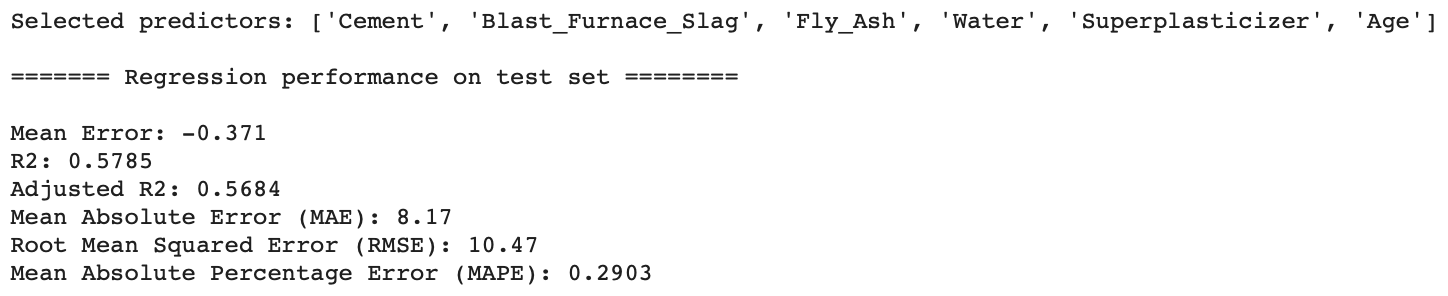

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 1) Forward selection with 4-fold CV (optimize R2)
base_model = LinearRegression()

sfs = SequentialFeatureSelector(
    estimator=base_model,
    n_features_to_select="auto",   # let it stop automatically
    direction="forward",
    scoring="r2",
    cv=4,
    tol=0.001                      # stop when R2 improvement < 0.001
)

# Fit SFS on TRAINING data only
sfs.fit(train_X, train_y)

# 2) Get selected feature names
selected_features = list(train_X.columns[sfs.get_support()])
print(f"Selected predictors: {selected_features}")

# 3) Train model using selected features on training set
fs_model = LinearRegression()
fs_model.fit(train_X[selected_features], train_y)

# 4) Predict on test set
test_pred = fs_model.predict(test_X[selected_features])

# 5) Compute metrics on test set
me = np.mean(test_y - test_pred)
r2 = r2_score(test_y, test_pred)
n = test_X.shape[0]
p = len(selected_features)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

mae = mean_absolute_error(test_y, test_pred)
rmse = np.sqrt(mean_squared_error(test_y, test_pred))

# IMPORTANT: MAPE as DECIMAL (matches example)
mape = np.mean(np.abs((test_y - test_pred) / test_y))

# 6) Print in the same format as the example
print("\n======= Regression performance on test set =======")
print(f"Mean Error: {me:.3f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")

fs_me_test = me
fs_r2_test = r2
fs_adj_r2_test = adj_r2
fs_mae_test = mae
fs_rmse_test = rmse
fs_mape_test = mape

SequentialFeatureSelector(cv=4, estimator=LinearRegression(), scoring='r2',
                          tol=0.001)

Selected predictors: ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Age']


LinearRegression()


======= Regression performance on test set =======
Mean Error: -0.371
R2: 0.5785
Adjusted R2: 0.5684
Mean Absolute Error (MAE): 8.17
Root Mean Squared Error (RMSE): 10.47
Mean Absolute Percentage Error (MAPE): 0.2903


### Step 3.4: Lasso regression model


- Train a Lasso regression model with 4-fold cross validation on the training set. Set the parameter alphas to [0.001, 0.01, 0.1, 1, 10], and tol to 0.001. Standarize all predictors before fitting.
- Print the alpha selected.
- Print the features with non-zero coefficients.
- calculate the following performance metrics on the test data:
    - $R^2$,
    - Adjusted $R^2$,
    - Mean Error,
    - Mean Absolute Error (MAE),
    - Root Mean Squared Error (RMSE), and
    - Mean Absolute Percentage Error (MAPE).

*Annotate each step with comments using `#`.*  

***Your display should look like this:***

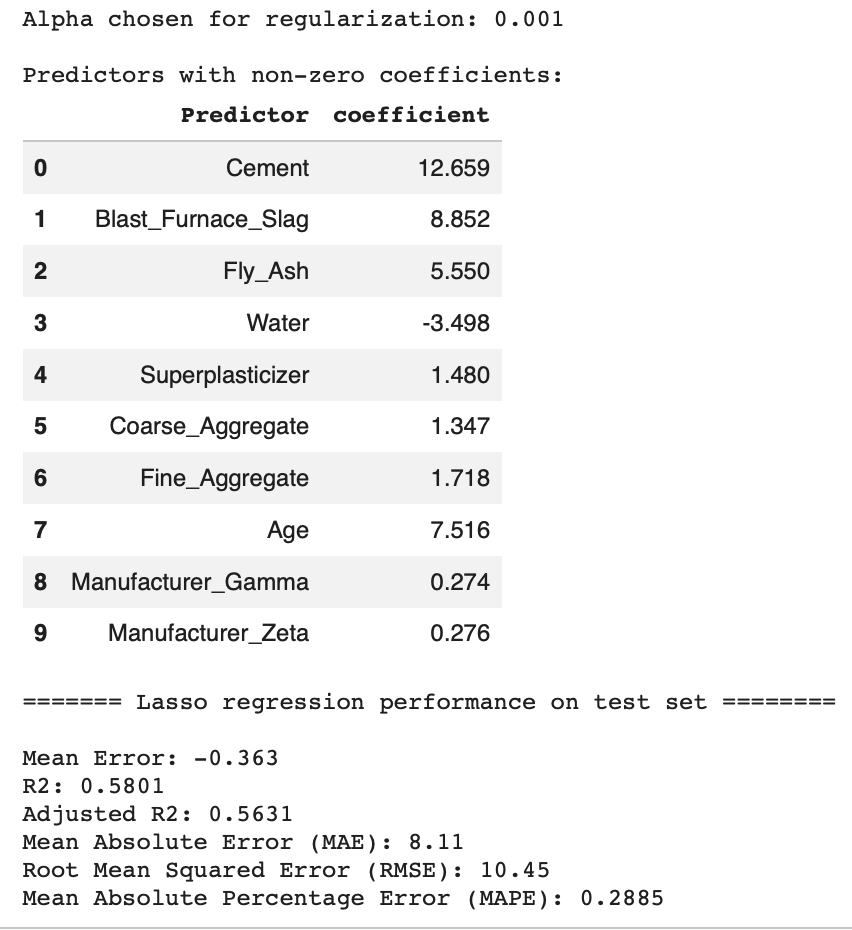

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ===================== Step 3.4: Lasso regression model =====================

# 1) Standardize predictors + fit Lasso with 4-fold CV to choose alpha
alphas = [0.001, 0.01, 0.1, 1, 10]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000))
])

grid = GridSearchCV(
    estimator=pipe,
    param_grid={"lasso__alpha": alphas},
    cv=4,
    scoring="r2"
)

grid.fit(train_X, train_y)

best_alpha = grid.best_params_["lasso__alpha"]
print(f"Alpha chosen for regularization: {best_alpha}")

# 2) Get non-zero coefficients (note: coefficients are on standardized features)
best_model = grid.best_estimator_
coefs = best_model.named_steps["lasso"].coef_

nonzero_mask = coefs != 0
nonzero_predictors = train_X.columns[nonzero_mask]
nonzero_coefs = coefs[nonzero_mask]

print("\nPredictors with non-zero coefficients:")
coef_df = pd.DataFrame({
    "Predictor": nonzero_predictors,
    "coefficient": nonzero_coefs
})
coef_df["coefficient"] = coef_df["coefficient"].round(3)
coef_df

# 3) Evaluate on test set (match the example format)
test_pred = best_model.predict(test_X)

me = np.mean(test_y - test_pred)
r2 = r2_score(test_y, test_pred)

n = test_X.shape[0]           # number of observations
p = len(nonzero_predictors)   # number of selected predictors (non-zero)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

mae = mean_absolute_error(test_y, test_pred)
rmse = np.sqrt(mean_squared_error(test_y, test_pred))
mape = np.mean(np.abs((test_y - test_pred) / test_y))  # decimal, not %

print("\n====== Lasso regression performance on test set ======")
print(f"Mean Error: {me:.3f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")

lasso_me_test = me
lasso_r2_test = r2
lasso_adj_r2_test = adj_r2
lasso_mae_test = mae
lasso_rmse_test = rmse
lasso_mape_test = mape

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lasso', Lasso(max_iter=10000))]),
             param_grid={'lasso__alpha': [0.001, 0.01, 0.1, 1, 10]},
             scoring='r2')

Alpha chosen for regularization: 0.001

Predictors with non-zero coefficients:


,Predictor,coefficient
0,Cement,12.660
1,Blast_Furnace_Slag,8.853
2,Fly_Ash,5.551
3,Water,-3.497
4,Superplasticizer,1.480
5,Coarse_Aggregate,1.348
6,Fine_Aggregate,1.719
7,Age,7.516
8,Manufacturer_Gamma,0.274
9,Manufacturer_Zeta,0.276



====== Lasso regression performance on test set ======
Mean Error: -0.363
R2: 0.5801
Adjusted R2: 0.5631
Mean Absolute Error (MAE): 8.11
Root Mean Squared Error (RMSE): 10.45
Mean Absolute Percentage Error (MAPE): 0.2885


### Step 3.5: Model comparison


- Collect the test performance metrics from Steps 3.2, 3.3, and 3.4 into a Dataframe, where each row presents a model and each column indicates a metric.
- Print out the Dataframe.

*Annotate each step with comments using `#`.*

 ***Your display should look like this:***

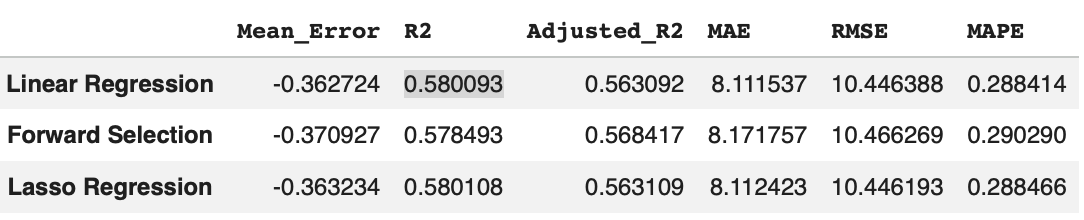

In [ ]:
import pandas as pd

# 1) Put the 3 metric dictionaries into a DataFrame (each dict = one row)
#    (These dictionaries MUST already exist from prior steps)
#    - pred_test_metrics  (from Step 3.2)
#    - fs_test_metrics    (from Step 3.3)
#    - lasso_test_metrics (from Step 3.4)
comparison_df = pd.DataFrame(
    [pred_test_metrics, fs_test_metrics, lasso_test_metrics],
    index=["Linear Regression", "Forward Selection", "Lasso Regression"]
)

# 2) Make sure the columns are in the same order as the screenshot
comparison_df = comparison_df[["Mean Error", "R2", "Adjusted R2", "MAE", "RMSE", "MAPE"]]

# 3) Rename columns to match the screenshot headers exactly
comparison_df = comparison_df.rename(columns={
    "Mean Error": "Mean_Error",
    "Adjusted R2": "Adjusted_R2"
})

# 4) Format numbers to match screenshot style
comparison_df["Mean_Error"]   = comparison_df["Mean_Error"].map(lambda x: f"{x:.6f}")
comparison_df["R2"]           = comparison_df["R2"].map(lambda x: f"{x:.6f}")
comparison_df["Adjusted_R2"]  = comparison_df["Adjusted_R2"].map(lambda x: f"{x:.6f}")
comparison_df["MAE"]          = comparison_df["MAE"].map(lambda x: f"{x:.6f}")
comparison_df["RMSE"]         = comparison_df["RMSE"].map(lambda x: f"{x:.6f}")
comparison_df["MAPE"]         = comparison_df["MAPE"].map(lambda x: f"{x:.6f}")

# 5) Display the comparison table
comparison_df

NameError: name 'pred_test_metrics' is not defined